# 02 - Implementation: Walking Through the Components
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yaso09/ddm/blob/master/notebooks/02_Implementation.ipynb)

**Summary.** This notebook opens each piece of the DDM implementation from
`src/ddm/models/` on tiny inputs and visualizes the intermediate tensors:

- the ALiBi slope schedule and the distance matrix,
- the learned gate $g(k)$ (and the fixed $1/k$ ablation curve),
- the causal mask and the segment-memory token (extra key/value column),
- the attention weights, and finally the full `DDMModel` forward pass
  (including the detached-memory guarantee and a numeric causality check).

All classes live in the package; this notebook only calls them.

In [ ]:
# --- Colab / Kaggle setup: clone the DDM repo and expose the package ---
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/yaso09/ddm.git"

def _find_repo_root() -> Path | None:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return None

ROOT = _find_repo_root()
if ROOT is None:
    # Fresh cloud environment (Colab/Kaggle): clone the repository.
    print("[setup] cloning DDM repository ...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "ddm"], check=True)
    ROOT = Path.cwd() / "ddm"

os.chdir(ROOT)
# The package lives under src/; add it so `import ddm` works.
sys.path.insert(0, str(ROOT / "src"))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)


In [1]:
# --- repo root bootstrap: lets the notebook run from any working directory ---
import os, sys
from pathlib import Path

def _find_root() -> Path:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return here

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
SMOKE = os.environ.get("DDM_SMOKE", "0") == "1"
print("repo root:", ROOT, "| DDM_SMOKE:", SMOKE)


repo root: C:\Users\yasir\Desktop\ammar | DDM_SMOKE: True


In [2]:
import math
import torch
import matplotlib.pyplot as plt

from ddm.models import DistanceAwareAttention, DDMModel

%matplotlib inline

## 1. ALiBi slopes and the distance matrix

The per-head slopes follow the geometric schedule
$m_h = 2^{-8h/n_{heads}}$, $h=1\dots n_{heads}$: nearby keys get the
smallest penalty on the first head and the largest on the last.

ALiBi slopes (head 0..3): [0.25, 0.0625, 0.015625, 0.00390625]
distance matrix (query rows, key cols):
 tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0],
        [2, 1, 0, 0, 0, 0, 0, 0],
        [3, 2, 1, 0, 0, 0, 0, 0],
        [4, 3, 2, 1, 0, 0, 0, 0],
        [5, 4, 3, 2, 1, 0, 0, 0],
        [6, 5, 4, 3, 2, 1, 0, 0],
        [7, 6, 5, 4, 3, 2, 1, 0]])


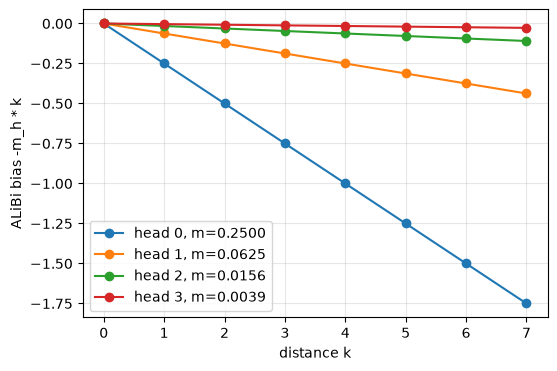

In [3]:
attn = DistanceAwareAttention(d_model=16, n_heads=4, learn_g=True, max_seq_len=16)
print("ALiBi slopes (head 0..3):", attn.alibi_slopes.tolist())

T = 8
q_idx = torch.arange(T).view(T, 1)
key_pos = torch.arange(T).view(1, T)
distance = (q_idx - key_pos).clamp(min=0)
print("distance matrix (query rows, key cols):\n", distance)

fig, ax = plt.subplots(figsize=(6, 4))
for h in range(attn.n_heads):
    ax.plot(torch.arange(T).float(), -attn.alibi_slopes[h] * torch.arange(T).float(),
            marker="o", label=f"head {h}, m={attn.alibi_slopes[h]:.4f}")
ax.set_xlabel("distance k"); ax.set_ylabel("ALiBi bias -m_h * k"); ax.grid(alpha=0.3)
ax.legend(); plt.show()

## 2. The distance gate g(k)

With `learn_g=True` the gate is `sigmoid(MLP(k / max_seq_len))` with
`MLP = Linear(1,16) -> ReLU -> Linear(16,1)`; with `learn_g=False` it is the
fixed curve $1/k$ (ablation). The initialization is random; after training
the curves become interpretable (see `05_Ablation.ipynb`).

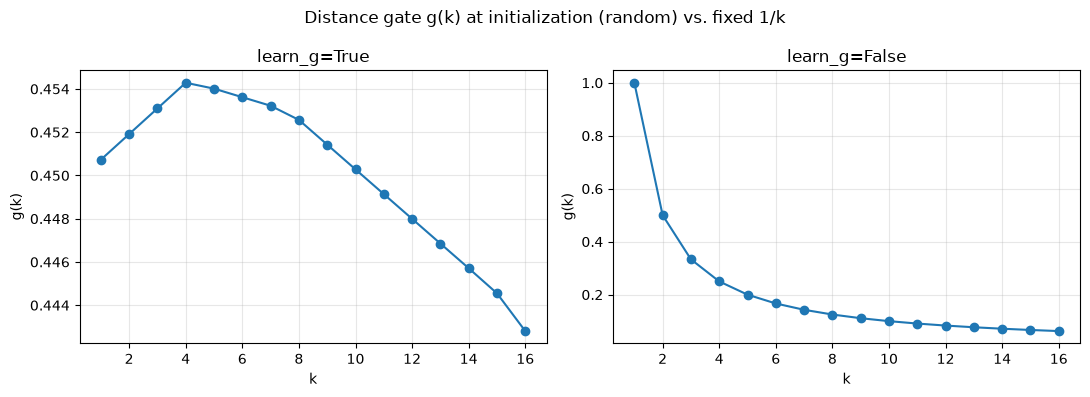

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, learn_g in zip(axes, (True, False), strict=True):
    a = DistanceAwareAttention(d_model=16, n_heads=4, learn_g=learn_g, max_seq_len=16)
    k = torch.arange(1, 17).float()
    with torch.no_grad():
        g = a.g(k)
    ax.plot(k.numpy(), g.numpy(), marker="o")
    ax.set_title("learn_g=" + str(learn_g))
    ax.set_xlabel("k"); ax.set_ylabel("g(k)"); ax.grid(alpha=0.3)
plt.suptitle("Distance gate g(k) at initialization (random) vs. fixed 1/k")
plt.tight_layout(); plt.show()

## 3. Segment memory: an extra always-visible key/value token

When a memory vector $M_{t-1}$ is passed, it is prepended to the keys/values
at virtual position $-1$; its distance from query $t$ is $t+1$ and the
causal mask always allows it. The key/value sequence becomes $T+1$ tokens.

no memory  : (1, 4, 8, 8)  | with memory: (1, 4, 8, 9)
attention on memory token per query (head 0): [0.477 0.271 0.142 0.117 0.097 0.063 0.048 0.042]
distance(query, memory): [1, 2, 3, 4, 5, 6, 7, 8]


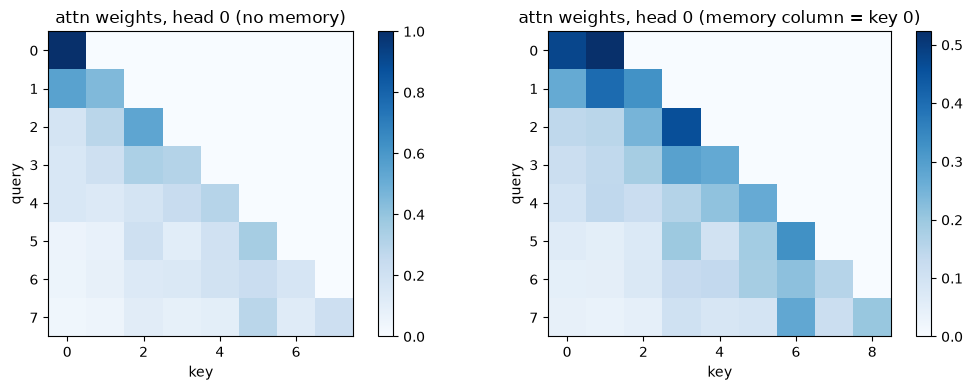

In [5]:
x = torch.randn(1, T, 16)
mem = torch.randn(1, 16)

with torch.no_grad():
    scores_no, attn_no = attn.get_attention_weights(x)
    scores_mem, attn_mem = attn.get_attention_weights(x, mem)

print("no memory  :", tuple(attn_no.shape), " | with memory:", tuple(attn_mem.shape))

# memory column carries attention mass for every query (never masked)
print("attention on memory token per query (head 0):",
      attn_mem[0, 0, :, 0].detach().numpy().round(3))

# distance of each query to the memory token is t+1
t = torch.arange(T)
print("distance(query, memory):", (t + 1).tolist())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(attn_no[0, 0].detach().numpy(), cmap="Blues")
axes[0].set_title("attn weights, head 0 (no memory)")
axes[0].set_xlabel("key"); axes[0].set_ylabel("query")
im1 = axes[1].imshow(attn_mem[0, 0].detach().numpy(), cmap="Blues")
axes[1].set_title("attn weights, head 0 (memory column = key 0)")
axes[1].set_xlabel("key"); axes[1].set_ylabel("query")
plt.colorbar(im0, ax=axes[0]); plt.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

## 4. The full model: forward pass, detached memory, causality

`DDMModel.forward(x, memory)` returns `(logits, new_memory)`; the new memory
is the (detached) mean of each block's hidden states. We verify:

- output shape `[B, T, V]`,
- `new_memory` carries no gradients,
- corrupting future inputs leaves past logits untouched (causal mask).

In [6]:
torch.manual_seed(0)
model = DDMModel(vocab_size=256, d_model=32, n_layers=2, n_heads=4, max_seq_len=64)

x = torch.randint(0, 256, (2, 32))
logits, new_mem = model(x)
print("logits:", tuple(logits.shape), "| new_memory:", len(new_mem),
      "| detached:", new_mem[0].requires_grad == False)  # noqa: E712

# causality: corrupt the future half
xc = x.clone()
xc[:, 16:] = torch.randint(0, 256, (2, 16))
logits_c, _ = model(xc)
ok = torch.allclose(logits[:, :16], logits_c[:, :16], atol=1e-5, rtol=1e-5)
print("past logits unchanged after corrupting the future:", ok)

logits: (2, 32, 256) | new_memory: 2 | detached: True
past logits unchanged after corrupting the future: True


## Summary

The toy runs confirm: distance-aware scores (ALiBi + log g(k)), the
always-visible memory token, the detached memory state and the strict
causality all behave as designed. The full pipeline (data, training,
evaluation) is exercised in `03_Training.ipynb`.